# Copernicus Solar Forecasting - notebook final ameliore

Version generee automatiquement depuis `Copernicus_notebook_final_rendu_propre.ipynb`.

Ajouts visibles dans cette version:

- features de mouvement nuageux et baseline `advective_csi`;
- features de texture spatiale GLCM et Gabor;
- branchement conditionnel pour variables exogenes de vent `U/V`;
- section Deep Learning orientee ConvLSTM;
- clustering enrichi avec mouvement et texture.

## Note de generation

Ce fichier est une nouvelle sortie separee. Le notebook propre d'origine n'est pas modifie par ce script.

Fichier source: `Copernicus_notebook_final_rendu_propre.ipynb`  
Fichier genere: `Copernicus_notebook_final_rendu_propre_ameliore.ipynb`

## 0. Setup & chargement

Par défaut, le notebook peut être lancé sur `sample` pour itérer rapidement.  
Pour les résultats finaux, il faut passer à `full`.  
La partie **deep learning** est prévue pour être lancée de préférence sur **Google Colab**.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from config import FORECAST_HORIZONS_MINUTES, INPUT_VARIABLES
from src.baselines import mean_image_baseline, persistence_csi_baseline, persistence_last_ghi_baseline
from src.data_loading import open_processed_profile, prepare_processed_profile, processed_profile_exists
from src.deep_learning import (
    add_residual_mean_to_baseline,
    build_convlstm_residual_model,
    build_convlstm_residual_model,
    build_convlstm_residual_model,
    build_small_residual_cnn,
    fit_mlp_residual_mean,
    has_tensorflow,
    prepare_cnn_training_data,
    prepare_convlstm_training_data,
    target_from_channels_last,
)
from src.eda import descriptive_stats, target_horizon_stats
from src.features import (
    build_advanced_features,
    build_physical_inputs,
    build_spatial_feature_tensor,
    build_tabular_features,
    build_exogenous_features,
)
from src.interpretation import (
    compute_tree_shap_values,
    model_feature_importances,
    permutation_importance_multioutput,
)
from src.metrics import (
    build_model_diagnostics,
    cluster_balance_report,
    cluster_quality,
    evaluate_model_bundle,
    evaluate_spatial_structure,
    global_metrics_row,
    metrics_by_cluster,
    rmse,
    spatial_mean_residual,
)
from src.motion import advective_csi_baseline, estimate_motion_vectors, has_opencv
from src.texture import build_texture_features
from src.preprocessing import temporal_train_validation_split
from src.visualization import horizon_titles, plot_sequence
from models.models_tabular import (
    fit_elasticnet_multioutput,
    fit_extra_trees_multioutput,
    fit_hist_gb_multioutput,
    fit_random_forest_multioutput,
    fit_ridge_multioutput,
    patchwise_predictions_to_map,
    patchwise_target_means,
)

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
PROFILE = "dev"   # "dev" / "sample" / "full"
RUN_FAST = PROFILE == "dev"
RUN_RIDGE = True
RUN_ELASTICNET = PROFILE in {"dev", "sample"}
RUN_RANDOM_FOREST = PROFILE in {"dev", "sample"}
RUN_EXTRA_TREES = True
RUN_HGB = True
RUN_PATCH_LOCAL = True
RUN_CLUSTER_AUG = True
RUN_DL = True   # plutôt sur Colab
RUN_OPTICAL_FLOW = True
RUN_TEXTURE_FEATURES = True
RUN_OPTICAL_FLOW = True
RUN_TEXTURE_FEATURES = True
RUN_OPTICAL_FLOW = True
RUN_TEXTURE_FEATURES = True
MAIN_REFERENCE_NAME = "persistence_csi"

np.random.seed(RANDOM_STATE)

In [2]:
if not processed_profile_exists(PROFILE, split="train"):
    prepare_processed_profile(PROFILE, split="train", overwrite=False)

data = open_processed_profile(PROFILE, split="train", variables=INPUT_VARIABLES, mmap_mode=None)
arrays = {name: np.asarray(values, dtype=np.float32) for name, values in data["X"].items()}
y = np.asarray(data["y"], dtype=np.float32)

available_variables = sorted(arrays)
wind_variables = [
    name for name in available_variables
    if name.lower() in {"u", "v", "u10", "v10", "wind_u", "wind_v"}
]
if len(wind_variables) == 0:
    print("Variables exogenes vent: non disponibles dans ce jeu Copernicus (GHI/CLS/SZA/SAA seulement).")
else:
    print("Variables exogenes vent detectees:", wind_variables)

train_idx, val_idx = temporal_train_validation_split(len(y), validation_fraction=0.2)
train_arrays_raw = {name: values[train_idx] for name, values in arrays.items()}
val_arrays_raw = {name: values[val_idx] for name, values in arrays.items()}
train_target = y[train_idx]
val_target = y[val_idx]

print(f"Profil: {PROFILE}")
print(f"Samples: total={len(y)}, train={len(train_idx)}, validation={len(val_idx)}")
print({name: value.shape for name, value in arrays.items()})
print("Target:", y.shape)

Variables exogenes vent: non disponibles dans ce jeu Copernicus (GHI/CLS/SZA/SAA seulement).
Profil: dev
Samples: total=32, train=25, validation=7
{'GHI': (32, 4, 51, 51), 'CLS': (32, 8, 51, 51), 'SZA': (32, 8, 51, 51), 'SAA': (32, 8, 51, 51)}
Target: (32, 4, 51, 51)


## 1. Problématique

Le challenge consiste à prévoir le rayonnement solaire global horizontal (GHI) sur les quatre horizons futurs `t+15`, `t+30`, `t+45` et `t+60` minutes, sous forme de cartes `51 × 51` pixels centrées sur la zone d'intérêt.

Les entrées combinent :
- les quatre dernières images `GHI` ;
- les huit images `CLS` (clear-sky) ;
- les angles solaires `SZA/SAA`.

La stratégie retenue consiste à comparer une **baseline physique forte** (`persistence_csi`) à des modèles tabulaires, puis à des variantes plus locales / plus spatiales.

## 2. EDA

Cette partie sert surtout à :
- vérifier que les ordres de grandeur sont cohérents ;
- constater que la difficulté augmente avec l'horizon ;
- garder en tête qu'on travaille sur des **cartes** et pas seulement sur une série univariée.

,variable,shape,mean,std,min,median,max
0,GHI,"(32, 4, 51, 51)",355.604126,131.799805,17.889999,380.309998,580.979980
1,CLS,"(32, 8, 51, 51)",389.052338,134.424789,95.919998,421.739990,609.080017
2,SZA,"(32, 8, 51, 51)",180.150284,33.024986,126.449997,180.184998,233.279999
3,SAA,"(32, 8, 51, 51)",67.739311,6.826277,58.700001,66.139999,82.550003
4,target,"(32, 4, 51, 51)",355.589783,131.513138,26.430000,382.890015,579.729980


,horizon_min,mean,std,min,median,max
0,15,361.582428,117.428726,34.930000,299.880005,551.900024
1,30,359.150726,123.477333,26.430000,335.345001,565.150024
2,45,354.447327,134.241776,54.919998,366.279999,574.450012
3,60,347.178741,148.341415,44.369999,390.829987,579.729980


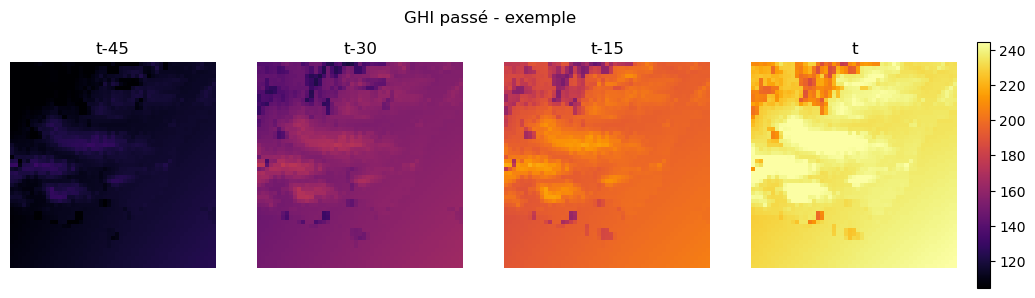

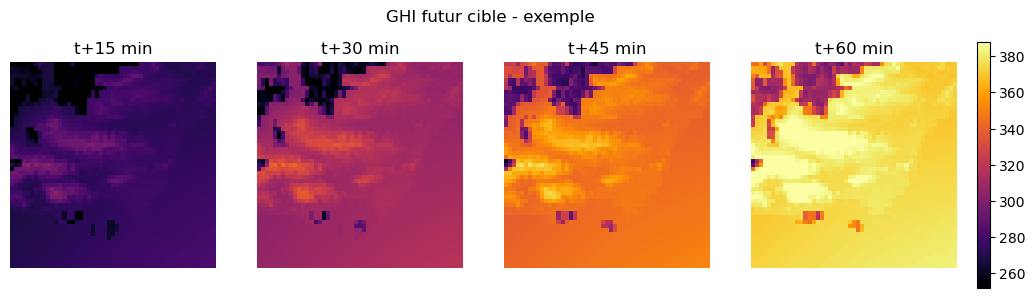

In [3]:
display(descriptive_stats(arrays, y))
display(target_horizon_stats(y))

sample_id = 0
plot_sequence(
    arrays["GHI"][sample_id],
    titles=["t-45", "t-30", "t-15", "t"],
    suptitle="GHI passé - exemple",
)
plt.show()

plot_sequence(
    y[sample_id],
    titles=horizon_titles(),
    suptitle="GHI futur cible - exemple",
)
plt.show()

### Interprétation de l’EDA

Les niveaux moyens du `GHI` observé et de la cible future sont cohérents, ce qui suggère l'absence de rupture artificielle entre entrées et sorties. En revanche, l'écart-type de la cible augmente avec l'horizon : plus on s'éloigne dans le futur, plus l'incertitude liée au déplacement et à l'évolution des nuages devient forte.

Ce comportement est exactement celui d'un problème de **nowcasting**. Il justifie :
- l'usage d'une baseline physique forte ;
- et la nécessité de comparer les modèles **par horizon**, pas seulement globalement.

## 3. Features enrichies

Les features conservent le socle physique (`CSI`, `CLS`, angles solaires), puis ajoutent trois ameliorations ciblees.

- Mouvement nuageux: estimation d'un deplacement dominant entre images successives. Si OpenCV est installe, Farneback peut etre utilise; sinon le notebook utilise une phase-correlation completee par le barycentre de nebulosite.
- Texture spatiale: descripteurs GLCM et Gabor sur le dernier CSI pour reperer les champs uniformes, stratus, ou les situations tres variables.
- Variables exogenes: le code accepte des composantes de vent `U/V` si elles existent dans une variante enrichie du dataset. Dans les fichiers actuels du challenge, elles ne sont pas presentes.

In [4]:
train_phys = build_physical_inputs(train_arrays_raw, keep_raw_ghi=True, encode_angles=True)
val_phys = build_physical_inputs(val_arrays_raw, keep_raw_ghi=True, encode_angles=True)

feature_blocks_train = [
    build_tabular_features(train_phys).add_prefix("phys_"),
    build_advanced_features(train_arrays_raw).add_prefix("adv_"),
]
feature_blocks_val = [
    build_tabular_features(val_phys).add_prefix("phys_"),
    build_advanced_features(val_arrays_raw).add_prefix("adv_"),
]

if RUN_OPTICAL_FLOW:
    train_motion_features = estimate_motion_vectors(train_phys["CSI"], use_farneback=None).add_prefix("flow_")
    val_motion_features = estimate_motion_vectors(val_phys["CSI"], use_farneback=None).add_prefix("flow_")
    feature_blocks_train.append(train_motion_features)
    feature_blocks_val.append(val_motion_features)
    print("Optical flow:", "Farneback/OpenCV" if has_opencv() else "phase-correlation + barycentre fallback")
    display(train_motion_features.describe().T)

if RUN_TEXTURE_FEATURES:
    train_texture_features = build_texture_features(train_phys, variable="CSI", time_index=-1).add_prefix("tex_")
    val_texture_features = build_texture_features(val_phys, variable="CSI", time_index=-1).add_prefix("tex_")
    feature_blocks_train.append(train_texture_features)
    feature_blocks_val.append(val_texture_features)
    display(train_texture_features.describe().T)

train_exogenous_features = build_exogenous_features(train_arrays_raw).add_prefix("exo_")
val_exogenous_features = build_exogenous_features(val_arrays_raw).add_prefix("exo_")
if len(train_exogenous_features.columns):
    feature_blocks_train.append(train_exogenous_features)
    feature_blocks_val.append(val_exogenous_features)
else:
    print("Aucune feature exogene vent ajoutee: variables U/V absentes des fichiers.")

X_train_features = pd.concat(feature_blocks_train, axis=1)
X_val_features = pd.concat(feature_blocks_val, axis=1)

common_cols = [col for col in X_train_features.columns if col in X_val_features.columns]
X_train_features = X_train_features[common_cols].replace([np.inf, -np.inf], np.nan)
X_val_features = X_val_features[common_cols].replace([np.inf, -np.inf], np.nan)
medians = X_train_features.median(numeric_only=True).fillna(0.0)
X_train_features = X_train_features.fillna(medians)
X_val_features = X_val_features.fillna(medians)

scaler = StandardScaler()
X_train_tab = scaler.fit_transform(X_train_features).astype(np.float32)
X_val_tab = scaler.transform(X_val_features).astype(np.float32)
feature_names = list(X_train_features.columns)

print("Feature matrix train:", X_train_tab.shape)
display(X_train_features.describe().T.head(30))

Optical flow: phase-correlation + barycentre fallback


,count,mean,std,min,25%,50%,75%,max
flow_motion_dx_mean,25.0,0.032105,0.297851,-0.530839,-0.191030,0.055685,0.276496,0.596412
flow_motion_dy_mean,25.0,0.049510,0.421107,-0.527297,-0.240001,-0.037762,0.300129,0.789479
flow_motion_dx_last,25.0,0.092677,0.328523,-0.575102,-0.077521,0.070145,0.246340,0.965114
flow_motion_dy_last,25.0,0.083913,0.385537,-0.520793,-0.197792,0.048520,0.276056,0.900200
flow_motion_speed_mean,25.0,0.463677,0.252405,0.100594,0.227509,0.442085,0.706808,0.880019
flow_motion_speed_last,25.0,0.411934,0.309980,0.057227,0.194312,0.277690,0.595274,1.274308
flow_motion_speed_p90,25.0,0.669768,0.361468,0.127048,0.329735,0.691194,0.935858,1.274308
flow_cloud_centroid_dx_mean,25.0,0.032105,0.297851,-0.530839,-0.191030,0.055685,0.276496,0.596412
flow_cloud_centroid_dy_mean,25.0,0.049510,0.421107,-0.527297,-0.240001,-0.037762,0.300129,0.789479
flow_cloud_centroid_dx_last,25.0,0.092677,0.328523,-0.575102,-0.077521,0.070145,0.246340,0.965114


,count,mean,std,min,25%,50%,75%,max
tex_csi_t-1_glcm_contrast,25.0,2.993382,1.278214,0.959406,2.010198,2.826138,4.220495,4.961683
tex_csi_t-1_glcm_dissimilarity,25.0,0.591038,0.272391,0.307426,0.381881,0.516931,0.666040,1.221485
tex_csi_t-1_glcm_homogeneity,25.0,0.841730,0.101487,0.591901,0.834054,0.880537,0.906745,0.950179
tex_csi_t-1_glcm_energy,25.0,0.592517,0.258723,0.135669,0.378199,0.731385,0.794213,0.857852
tex_csi_t-1_glcm_entropy,25.0,2.179122,1.108281,0.969033,1.322437,1.760022,3.001259,4.415585
tex_csi_t-1_gabor_mean,25.0,0.573739,0.168158,0.329806,0.448549,0.554040,0.671086,0.958946
tex_csi_t-1_gabor_max_mean,25.0,0.828636,0.264231,0.464725,0.634552,0.748264,1.001511,1.452114
tex_csi_t-1_gabor_p90,25.0,1.610588,0.453682,0.576255,1.274404,1.655120,1.990486,2.183310
tex_csi_t-1_gabor_max_p90,25.0,2.394207,0.649544,0.941041,1.889117,2.453299,2.824962,3.520066


Aucune feature exogene vent ajoutee: variables U/V absentes des fichiers.


Feature matrix train: (25, 610)


,count,mean,std,min,25%,50%,75%,max
phys_CSI_mean_t0,25.0,0.899106,0.054257,0.753555,0.868857,0.911917,0.942508,0.955942
phys_CSI_std_t0,25.0,0.063628,0.049308,0.008385,0.022458,0.043531,0.100722,0.179634
phys_CSI_min_t0,25.0,0.545388,0.225348,0.146619,0.370519,0.561725,0.746266,0.804558
phys_CSI_max_t0,25.0,0.939594,0.024678,0.899546,0.901855,0.949561,0.954663,0.961201
phys_CSI_mean_t1,25.0,0.901987,0.053930,0.738969,0.873321,0.912456,0.942395,0.956308
phys_CSI_std_t1,25.0,0.062721,0.049205,0.008267,0.024600,0.039261,0.107361,0.179119
phys_CSI_min_t1,25.0,0.539030,0.241684,0.103893,0.335327,0.611761,0.746876,0.838310
phys_CSI_max_t1,25.0,0.942621,0.018905,0.912670,0.914610,0.946594,0.956666,0.960563
phys_CSI_mean_t2,25.0,0.904028,0.053292,0.734810,0.876670,0.912384,0.938094,0.956107
phys_CSI_std_t2,25.0,0.060346,0.047492,0.006782,0.028544,0.038015,0.096752,0.165990


In [5]:
spatial_train_tensor, spatial_feature_names = build_spatial_feature_tensor(train_phys)
print("Tenseur spatial pour CNN:", spatial_train_tensor.shape)
print("Premiers canaux:", spatial_feature_names[:12])

Tenseur spatial pour CNN: (25, 51, 51, 51)
Premiers canaux: ['CSI_t0', 'CSI_t1', 'CSI_t2', 'CSI_t3', 'CLS_t0', 'CLS_t1', 'CLS_t2', 'CLS_t3', 'CLS_t4', 'CLS_t5', 'CLS_t6', 'CLS_t7']


### Justification des features retenues

Les features tabulaires resument le niveau moyen, la dispersion et la dynamique temporelle. Les features de mouvement apportent une information directionnelle: elles repondent a la limite de la persistance statique, qui suppose implicitement que les masses nuageuses restent au meme endroit. Les features de texture completent le clustering, car deux situations peuvent avoir le meme CSI moyen mais une organisation spatiale tres differente.

## 4. Baselines

La baseline principale est la persistance CSI : on conserve le dernier clear-sky index observé, puis on le réinjecte dans le `CLS` futur connu.  
C'est une référence plus exigeante et plus physique que la persistance brute du dernier `GHI`.

In [6]:
y_pred_persistence_raw = persistence_last_ghi_baseline(val_arrays_raw)
y_pred_persistence_csi = persistence_csi_baseline(val_arrays_raw)
y_pred_mean = mean_image_baseline(train_target, n_samples=len(val_target))
y_pred_train_csi = persistence_csi_baseline(train_arrays_raw)

# Persistance advective: on deplace le dernier CSI selon le mouvement estime.
if RUN_OPTICAL_FLOW:
    y_pred_advective_csi = advective_csi_baseline(
        val_arrays_raw,
        motion_features=val_motion_features.rename(columns=lambda col: col.replace("flow_", "")),
    )
    y_pred_train_advective_csi = advective_csi_baseline(
        train_arrays_raw,
        motion_features=train_motion_features.rename(columns=lambda col: col.replace("flow_", "")),
    )
else:
    y_pred_advective_csi = y_pred_persistence_csi
    y_pred_train_advective_csi = y_pred_train_csi

predictions = {
    "persistence_raw": y_pred_persistence_raw,
    "persistence_csi": y_pred_persistence_csi,
    "advective_csi": y_pred_advective_csi,
    "mean_image": y_pred_mean,
}

csi_reference_rmse = rmse(val_target, y_pred_persistence_csi)
baseline_table = pd.DataFrame(
    [
        global_metrics_row(name, val_target, pred, csi_reference_rmse)
        for name, pred in predictions.items()
    ]
).sort_values("RMSE")
display(baseline_table)

,model,RMSE,MAE,MBE,MedAE,P90AE,nRMSE,R2,MAPE,corr_spatial_mean,skill_RMSE_vs_CSI
1,persistence_csi,13.692846,7.372206,-0.417489,3.536774,19.419833,0.037290,0.990239,2.556798,0.999774,5.333511e-11
2,advective_csi,18.462959,9.137542,-0.139323,3.626373,24.591437,0.050280,0.982254,3.224402,0.999755,-8.180892e-01
0,persistence_raw,77.652985,63.439056,18.745708,44.149979,131.770004,0.211473,0.686080,27.925336,0.839601,-3.116095e+01
3,mean_image,138.899038,125.968348,-14.861553,128.661423,199.910825,0.378265,-0.004387,50.034306,0.081565,-1.018990e+02


### Analyse des baselines

La baseline `persistence_csi` reste la reference du skill score. `advective_csi` teste une hypothese plus ambitieuse: conserver la structure de CSI mais la deplacer dans la direction estimee du mouvement nuageux. Sur petit echantillon, elle peut etre instable; sur `sample` ou `full`, elle indique si le mouvement apporte reellement de l'information.

## 5. Clustering non supervisé

Le clustering sert à segmenter les régimes de ciel pour mieux comprendre :
- dans quels régimes la baseline est déjà très forte ;
- dans quels régimes les modèles gagnent vraiment.

Ici, le clustering reste un **outil d'analyse**, pas un substitut au modèle supervisé.

In [7]:
cluster_feature_candidates = [
    col for col in feature_names
    if any(token in col for token in ["CSI_mean", "CSI_std", "CSI_trend", "GHI_mean", "GHI_std", "adv_csi", "flow_", "tex_"])
]
cluster_feature_names = cluster_feature_candidates if len(cluster_feature_candidates) >= 3 else feature_names

X_cluster_train = X_train_features[cluster_feature_names].to_numpy(dtype=np.float32)
X_cluster_val = X_val_features[cluster_feature_names].to_numpy(dtype=np.float32)

cluster_scaler = StandardScaler()
X_cluster_train_scaled = cluster_scaler.fit_transform(X_cluster_train)
X_cluster_val_scaled = cluster_scaler.transform(X_cluster_val)

cluster_pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_cluster_train_emb = cluster_pca.fit_transform(X_cluster_train_scaled)
X_cluster_val_emb = cluster_pca.transform(X_cluster_val_scaled)

k_values = [2, 3] if RUN_FAST else [2, 3, 4, 5]
cluster_rows = []
best_silhouette = -np.inf
best_k = None
best_kmeans = None

min_cluster_size_required = max(8, int(0.05 * len(X_cluster_train_emb)))

for k in k_values:
    km = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_cluster_train_emb)
    quality = cluster_quality(X_cluster_train_emb, labels)
    qmap = dict(zip(quality["metric"], quality["value"])) if not quality.empty else {}
    counts = pd.Series(labels).value_counts()
    row = {
        "k": k,
        "silhouette": qmap.get("silhouette", np.nan),
        "calinski_harabasz": qmap.get("calinski_harabasz", np.nan),
        "davies_bouldin": qmap.get("davies_bouldin", np.nan),
        "min_cluster_size": int(counts.min()),
        "max_cluster_share": float((counts / counts.sum()).max()),
    }
    cluster_rows.append(row)

    if row["min_cluster_size"] >= min_cluster_size_required and row["silhouette"] > best_silhouette:
        best_silhouette = row["silhouette"]
        best_k = k
        best_kmeans = km

cluster_search = pd.DataFrame(cluster_rows).sort_values("silhouette", ascending=False)
display(cluster_search)

if best_kmeans is None:
    best_k = int(cluster_search.iloc[0]["k"])
    best_kmeans = KMeans(n_clusters=best_k, n_init=30, random_state=RANDOM_STATE).fit(X_cluster_train_emb)
    print("Aucun k ne respecte la contrainte de taille sur ce petit profil; fallback au meilleur silhouette.")

print("Best k:", best_k)

train_clusters = best_kmeans.predict(X_cluster_train_emb)
val_clusters = best_kmeans.predict(X_cluster_val_emb)

display(cluster_balance_report(train_clusters))
display(cluster_balance_report(val_clusters))

cluster_frame = X_val_features.copy()
cluster_frame["cluster"] = val_clusters
csi_cols = [col for col in cluster_frame.columns if "CSI_mean_t3" in col or "csi_last_frame_mean" in col]
csi_label_col = csi_cols[0] if csi_cols else cluster_feature_names[0]

cluster_summary = (
    cluster_frame
    .groupby("cluster")
    .agg(n=(csi_label_col, "size"), csi_level=(csi_label_col, "mean"))
    .sort_values("csi_level")
)
ordered_clusters = list(cluster_summary.index)
weather_names = ["couvert", "partiellement_nuageux", "ciel_clair", "très_clair", "très_variable"]
cluster_name_map = {cluster: weather_names[i] for i, cluster in enumerate(ordered_clusters)}
cluster_summary["regime"] = [cluster_name_map[idx] for idx in cluster_summary.index]
display(cluster_summary.reset_index())

,k,silhouette,calinski_harabasz,davies_bouldin,min_cluster_size,max_cluster_share
1,3,0.265257,8.792682,1.346354,6,0.48
0,2,0.248023,9.419494,1.528687,11,0.56


Best k: 2


,cluster,n,share
0,0,14,0.56
1,1,11,0.44


,cluster,n,share
0,0,3,0.428571
1,1,4,0.571429


,cluster,n,csi_level,regime
0,1,4,0.896502,couvert
1,0,3,0.940685,partiellement_nuageux


In [8]:
CSI_CLEAR_THRESHOLD = 0.95

cluster_diag = X_val_features.copy()
cluster_diag["cluster"] = val_clusters

candidate_cols = [col for col in cluster_diag.columns if "phys_CSI_mean_t3" in col]
if len(candidate_cols) == 0:
    raise ValueError("La colonne 'phys_CSI_mean_t3' est introuvable dans X_val_features.")
csi_col = candidate_cols[0]

cluster_diag["is_quasi_clear"] = cluster_diag[csi_col] >= CSI_CLEAR_THRESHOLD

quasi_clear_by_cluster = (
    cluster_diag
    .groupby("cluster")
    .agg(
        n=(csi_col, "size"),
        csi_mean=(csi_col, "mean"),
        csi_std=(csi_col, "std"),
        quasi_clear_count=("is_quasi_clear", "sum"),
        quasi_clear_share=("is_quasi_clear", "mean"),
    )
    .reset_index()
)
quasi_clear_by_cluster["regime"] = quasi_clear_by_cluster["cluster"].map(cluster_name_map)
quasi_clear_by_cluster["quasi_clear_share"] = (100 * quasi_clear_by_cluster["quasi_clear_share"]).round(1)

display(quasi_clear_by_cluster.sort_values("csi_mean"))

examples_per_cluster = (
    cluster_diag
    .assign(row_id=np.arange(len(cluster_diag)))
    .sort_values(["cluster", csi_col], ascending=[True, False])
    .groupby("cluster")
    .head(5)[["cluster", "row_id", csi_col, "is_quasi_clear"]]
)
examples_per_cluster["regime"] = examples_per_cluster["cluster"].map(cluster_name_map)
display(examples_per_cluster)

,cluster,n,csi_mean,csi_std,quasi_clear_count,quasi_clear_share,regime
1,1,4,0.896502,0.022406,0,0.0,couvert
0,0,3,0.940685,0.009586,1,33.3,partiellement_nuageux


,cluster,row_id,phys_CSI_mean_t3,is_quasi_clear,regime
5,0,5,0.951661,True,partiellement_nuageux
4,0,4,0.936435,False,partiellement_nuageux
6,0,6,0.933959,False,partiellement_nuageux
0,1,0,0.918015,False,couvert
3,1,3,0.902575,False,couvert
1,1,1,0.900398,False,couvert
2,1,2,0.865019,False,couvert


### Lecture du clustering

Le clustering utilise désormais les niveaux de CSI/GHI, la dynamique temporelle, les features de mouvement et les textures. Les régimes ne sont pas des classes météo observées: ce sont des segments statistiques que l'on interprète ensuite via le niveau de CSI, la part de ciel quasi clair, la texture et les performances par cluster.

In [9]:
cluster_tables = [
    metrics_by_cluster(
        val_target,
        y_pred_persistence_csi,
        val_clusters,
        "persistence_csi",
        cluster_name_map=cluster_name_map,
        reference_pred=y_pred_persistence_csi,
    )
]
cluster_baseline_perf = pd.concat(cluster_tables, ignore_index=True)
display(cluster_baseline_perf)

,model,cluster,regime,n,RMSE,MAE,bias,P90AE,nRMSE,skill_RMSE_vs_CSI
0,persistence_csi,0,partiellement_nuageux,3,8.811502,4.346719,-0.090239,6.155542,0.022746,1.287953e-10
1,persistence_csi,1,couvert,4,16.428105,9.641323,-0.662926,24.035141,0.046663,3.705314e-11


### Analyse des performances par régime

Si le régime couvert reste beaucoup plus difficile que le régime clair / partiellement nuageux, c'est normal : la dynamique des nuages y est plus perturbée.  
Le clustering sert donc surtout à montrer **où** les modèles gagnent et **où** la baseline reste déjà très forte.

## 6. Modèles supervisés — correction résiduelle moyenne

On commence par la version la plus simple : les modèles tabulaires apprennent un **résidu moyen par horizon**, qui est ensuite ajouté à la baseline CSI.  
Cette version sert de point de départ, mais on s'attend à ce qu'elle améliore surtout le **niveau moyen spatial**, pas forcément la structure fine.

In [10]:
residual_train = spatial_mean_residual(train_target, y_pred_train_csi)
residual_val = spatial_mean_residual(val_target, y_pred_persistence_csi)

model_registry = {}
supervised_predictions = {}

if RUN_RIDGE:
    ridge_model = fit_ridge_multioutput(X_train_tab, residual_train, alpha=10.0, random_state=RANDOM_STATE)
    ridge_residual = ridge_model.predict(X_val_tab)
    supervised_predictions["ridge_residual_csi"] = add_residual_mean_to_baseline(y_pred_persistence_csi, ridge_residual)
    model_registry["ridge_residual_csi"] = ridge_model

if RUN_ELASTICNET:
    elastic_model = fit_elasticnet_multioutput(
        X_train_tab,
        residual_train,
        alpha=0.001,
        l1_ratio=0.2,
        random_state=RANDOM_STATE,
        max_iter=2000,
    )
    elastic_residual = elastic_model.predict(X_val_tab)
    supervised_predictions["elasticnet_residual_csi"] = add_residual_mean_to_baseline(y_pred_persistence_csi, elastic_residual)
    model_registry["elasticnet_residual_csi"] = elastic_model

if RUN_RANDOM_FOREST:
    rf_model = fit_random_forest_multioutput(
        X_train_tab,
        residual_train,
        n_estimators=30 if RUN_FAST else 150,
        max_depth=6 if RUN_FAST else None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
    )
    rf_residual = rf_model.predict(X_val_tab)
    supervised_predictions["random_forest_residual_csi"] = add_residual_mean_to_baseline(y_pred_persistence_csi, rf_residual)
    model_registry["random_forest_residual_csi"] = rf_model

if RUN_EXTRA_TREES:
    extra_model = fit_extra_trees_multioutput(
        X_train_tab,
        residual_train,
        n_estimators=40 if RUN_FAST else 200,
        max_depth=8 if RUN_FAST else None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
    )
    extra_residual = extra_model.predict(X_val_tab)
    supervised_predictions["extra_trees_residual_csi"] = add_residual_mean_to_baseline(y_pred_persistence_csi, extra_residual)
    model_registry["extra_trees_residual_csi"] = extra_model

### Optimisation de HistGradientBoosting

HistGB est un bon candidat ici car il gère bien les non-linéarités tabulaires tout en restant relativement rapide.  
La petite recherche ci-dessous reste **chronologique** pour éviter une fuite temporelle.

In [11]:
inner_train_idx, inner_val_idx = temporal_train_validation_split(len(residual_train), validation_fraction=0.25)
X_inner_train, X_inner_val = X_train_tab[inner_train_idx], X_train_tab[inner_val_idx]
y_inner_train, y_inner_val = residual_train[inner_train_idx], residual_train[inner_val_idx]

hgb_grid = [
    {
        "learning_rate": [0.05, 0.10] if RUN_FAST else [0.03, 0.05, 0.08],
        "max_iter": [40] if RUN_FAST else [120, 200],
        "max_leaf_nodes": [15, 31],
        "min_samples_leaf": [5] if RUN_FAST else [10, 20],
        "l2_regularization": [0.0, 0.1] if not RUN_FAST else [0.0],
    }
]

hgb_rows = []
best_hgb_score = np.inf
best_hgb_params = None

for params in ParameterGrid(hgb_grid):
    candidate = fit_hist_gb_multioutput(
        X_inner_train,
        y_inner_train,
        learning_rate=params["learning_rate"],
        max_iter=params["max_iter"],
        max_leaf_nodes=params["max_leaf_nodes"],
        min_samples_leaf=params["min_samples_leaf"],
        l2_regularization=params["l2_regularization"],
        early_stopping=True,
        validation_fraction=0.2,
        random_state=RANDOM_STATE,
    )
    pred = candidate.predict(X_inner_val)
    score = float(np.sqrt(np.mean((pred - y_inner_val) ** 2)))

    row = dict(params)
    row["inner_RMSE_residual_mean"] = score
    hgb_rows.append(row)

    if score < best_hgb_score:
        best_hgb_score = score
        best_hgb_params = params

hgb_tuning = pd.DataFrame(hgb_rows).sort_values("inner_RMSE_residual_mean")
display(hgb_tuning)
print("Best HistGB params:", best_hgb_params)

if RUN_HGB:
    hgb_model = fit_hist_gb_multioutput(
        X_train_tab,
        residual_train,
        learning_rate=best_hgb_params["learning_rate"],
        max_iter=best_hgb_params["max_iter"],
        max_leaf_nodes=best_hgb_params["max_leaf_nodes"],
        min_samples_leaf=best_hgb_params["min_samples_leaf"],
        l2_regularization=best_hgb_params["l2_regularization"],
        early_stopping=True,
        validation_fraction=0.2,
        random_state=RANDOM_STATE,
    )
    hgb_residual = hgb_model.predict(X_val_tab)
    supervised_predictions["hist_gb_residual_csi"] = add_residual_mean_to_baseline(y_pred_persistence_csi, hgb_residual)
    model_registry["hist_gb_residual_csi"] = hgb_model

,l2_regularization,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,inner_RMSE_residual_mean
3,0.0,0.10,40,31,5,6.889679
2,0.0,0.10,40,15,5,6.889679
1,0.0,0.05,40,31,5,7.336298
0,0.0,0.05,40,15,5,7.336298


Best HistGB params: {'l2_regularization': 0.0, 'learning_rate': 0.1, 'max_iter': 40, 'max_leaf_nodes': 15, 'min_samples_leaf': 5}


In [12]:
predictions_mean = {**predictions, **supervised_predictions}
diagnostics_mean = build_model_diagnostics(val_target, predictions_mean, reference_name=MAIN_REFERENCE_NAME)

global_comparison = diagnostics_mean["global"]
horizon_comparison = diagnostics_mean["by_horizon"]
spatial_mean_comparison = diagnostics_mean["spatial_means"]
spatial_structure_comparison = diagnostics_mean["spatial_structure"]

display(global_comparison)
display(horizon_comparison.sort_values(["horizon_min", "RMSE"]))
display(spatial_mean_comparison.sort_values(["horizon_min", "RMSE_spatial_mean"]))
display(spatial_structure_comparison.sort_values(["horizon_min", "RMSE_structure"]))

,model,RMSE,MAE,MBE,MedAE,P90AE,nRMSE,R2,MAPE,corr_spatial_mean,skill_RMSE_vs_CSI
0,random_forest_residual_csi,13.284251,6.394910,0.072374,1.884956,19.243642,0.036177,0.990813,2.110221,0.999985,5.878961e-02
1,extra_trees_residual_csi,13.306444,6.325711,0.271465,1.691467,19.105670,0.036238,0.990782,2.091431,0.999959,5.564223e-02
2,hist_gb_residual_csi,13.350894,6.699421,0.337312,2.685139,19.355685,0.036359,0.990721,2.186785,0.999948,4.932240e-02
3,ridge_residual_csi,13.384689,6.527440,-0.144588,1.889633,19.330798,0.036451,0.990673,2.151840,0.999911,4.450349e-02
4,elasticnet_residual_csi,13.498168,6.846403,-0.376817,2.025558,19.517313,0.036760,0.990515,2.273741,0.999863,2.823293e-02
5,persistence_csi,13.692846,7.372206,-0.417489,3.536774,19.419833,0.037290,0.990239,2.556798,0.999774,5.333511e-11
6,advective_csi,18.462959,9.137542,-0.139323,3.626373,24.591437,0.050280,0.982254,3.224402,0.999755,-8.180892e-01
7,persistence_raw,77.652985,63.439056,18.745708,44.149979,131.770004,0.211473,0.686080,27.925336,0.839601,-3.116095e+01
8,mean_image,138.899038,125.968348,-14.861553,128.661423,199.910825,0.378265,-0.004387,50.034306,0.081565,-1.018990e+02


,horizon_min,RMSE,MAE,bias,P90AE,corr_spatial_mean,skill_RMSE_vs_ref,skill_MAE_vs_ref,model
16,15,7.575203,3.738998,-0.021940,12.148083,0.999985,1.680367e-02,9.701760e-02,ridge_residual_csi
24,15,7.582843,3.688840,0.231039,12.274042,0.999994,1.581210e-02,1.091310e-01,random_forest_residual_csi
28,15,7.588448,3.616462,0.322827,12.284351,0.999988,1.508465e-02,1.266105e-01,extra_trees_residual_csi
32,15,7.602896,3.858444,0.240924,12.273474,0.999982,1.320940e-02,6.817083e-02,hist_gb_residual_csi
20,15,7.629263,4.010152,-0.388502,12.115265,0.999965,9.787247e-03,3.153283e-02,elasticnet_residual_csi
4,15,7.704670,4.140720,0.153411,12.326263,0.999932,1.297914e-09,2.415039e-09,persistence_csi
8,15,11.003035,5.238712,0.324207,15.538455,0.999922,-4.280995e-01,-2.651693e-01,advective_csi
0,15,28.998959,25.867481,5.097173,40.680008,0.971705,-2.763816e+00,-5.247097e+00,persistence_raw
12,15,121.229709,117.251295,-24.661142,150.167792,NaN,-1.473457e+01,-2.731664e+01,mean_image
29,30,11.363759,5.459178,0.244138,17.508044,0.999985,2.589922e-02,1.545298e-01,extra_trees_residual_csi


,horizon_min,RMSE_spatial_mean,MAE_spatial_mean,model
16,15,0.635511,0.512460,ridge_residual_csi
24,15,0.720891,0.567239,random_forest_residual_csi
28,15,0.777633,0.669002,extra_trees_residual_csi
32,15,0.907854,0.655667,hist_gb_residual_csi
20,15,1.107166,0.850114,elasticnet_residual_csi
4,15,1.543409,1.294094,persistence_csi
8,15,1.606110,1.410084,advective_csi
0,15,27.887018,25.339949,persistence_raw
12,15,117.911202,116.039775,mean_image
29,30,1.176486,0.895198,extra_trees_residual_csi


,horizon_min,RMSE_structure,MAE_structure,model
24,15,7.548498,3.681172,random_forest_residual_csi
28,15,7.548498,3.681173,extra_trees_residual_csi
4,15,7.548498,3.681173,persistence_csi
32,15,7.548499,3.681173,hist_gb_residual_csi
20,15,7.548499,3.681173,elasticnet_residual_csi
16,15,7.548499,3.681173,ridge_residual_csi
0,15,7.953230,4.136251,persistence_raw
8,15,10.885183,4.840399,advective_csi
12,15,28.170745,17.029748,mean_image
25,30,11.302693,5.462851,random_forest_residual_csi


### Lecture des modèles de correction moyenne

Les modèles ensemblistes sont généralement meilleurs que les modèles linéaires, mais le gain reste souvent **modéré**.  
La lecture importante est la suivante :

- si `RMSE_spatial_mean` s'améliore, le modèle corrige mieux le **niveau global** ;
- si `RMSE_structure` ne bouge presque pas, le modèle ne corrige pas vraiment la **forme spatiale**.

C'est précisément ce qui motive la section suivante.

## 7. Modèle tabulaire local par patches

Ici, on ne prédit plus un seul résidu moyen par horizon, mais un résidu **par patch** (grille `2×2`).  
On reste en tabulaire, mais on autorise le modèle à corriger différemment plusieurs zones de la carte.

In [13]:
spatial_predictions = {}

if RUN_PATCH_LOCAL:
    residual_train_maps = train_target - y_pred_train_csi
    residual_val_maps = val_target - y_pred_persistence_csi

    residual_patch_train, patch_names = patchwise_target_means(residual_train_maps, n_rows=2, n_cols=2)
    residual_patch_val, _ = patchwise_target_means(residual_val_maps, n_rows=2, n_cols=2)

    print("Patch target shape:", residual_patch_train.shape)
    print("Patch names:", patch_names[:8], "...")

    patch_hgb_model = fit_hist_gb_multioutput(
        X_train_tab,
        residual_patch_train,
        learning_rate=0.05,
        max_iter=150,
        max_leaf_nodes=15,
        min_samples_leaf=10,
        l2_regularization=0.1,
        random_state=RANDOM_STATE,
    )

    patch_pred_val = patch_hgb_model.predict(X_val_tab)

    y_pred_patch_hgb = patchwise_predictions_to_map(
        y_pred_persistence_csi,
        patch_pred_val,
        n_rows=2,
        n_cols=2,
    )

    spatial_predictions["hist_gb_patch2x2_residual_csi"] = y_pred_patch_hgb
    model_registry["hist_gb_patch2x2_residual_csi"] = patch_hgb_model

    patch_hgb_results = evaluate_model_bundle(
        val_target,
        y_pred_patch_hgb,
        model_name="hist_gb_patch2x2_residual_csi",
    )

    display(patch_hgb_results["global"])
    display(patch_hgb_results["by_horizon"])
    display(patch_hgb_results["spatial_means"])
    display(evaluate_spatial_structure(val_target, y_pred_patch_hgb))
else:
    print("RUN_PATCH_LOCAL = False")

Patch target shape: (25, 16)
Patch names: ['h0_r0_c0', 'h0_r0_c1', 'h0_r1_c0', 'h0_r1_c1', 'h1_r0_c0', 'h1_r0_c1', 'h1_r1_c0', 'h1_r1_c1'] ...


,metric,value,model
0,RMSE,13.564344,hist_gb_patch2x2_residual_csi
1,MAE,7.192806,hist_gb_patch2x2_residual_csi
2,MBE,1.611464,hist_gb_patch2x2_residual_csi
3,MedAE,2.884918,hist_gb_patch2x2_residual_csi
4,P90AE,19.355176,hist_gb_patch2x2_residual_csi
5,nRMSE,0.036940,hist_gb_patch2x2_residual_csi
6,R2,0.990421,hist_gb_patch2x2_residual_csi
7,MAPE,2.500134,hist_gb_patch2x2_residual_csi
8,corr_spatial_mean,0.999936,hist_gb_patch2x2_residual_csi


,horizon_min,RMSE,MAE,model
0,15,7.695015,4.046648,hist_gb_patch2x2_residual_csi
1,30,11.599156,6.237622,hist_gb_patch2x2_residual_csi
2,45,15.207763,8.470843,hist_gb_patch2x2_residual_csi
3,60,17.633377,10.016113,hist_gb_patch2x2_residual_csi


,horizon_min,RMSE_spatial_mean,MAE_spatial_mean,model
0,15,1.366752,1.121288,hist_gb_patch2x2_residual_csi
1,30,2.163502,1.612320,hist_gb_patch2x2_residual_csi
2,45,2.384469,2.084713,hist_gb_patch2x2_residual_csi
3,60,3.801819,3.101329,hist_gb_patch2x2_residual_csi


,horizon_min,RMSE_structure,MAE_structure
0,15,7.572665,3.978691
1,30,11.395599,6.129822
2,45,15.019666,8.212861
3,60,17.218657,9.552343


### Comment lire le modèle patch-wise

Si ce modèle améliore enfin les métriques de **structure spatiale**, cela signifie qu'une correction locale simple suffit déjà à mieux capturer l'hétérogénéité du champ.  
S'il améliore surtout la moyenne spatiale, alors même ce niveau local reste insuffisant — et la suite naturelle est un **vrai modèle spatial** (CNN résiduelle).

## 8. Spécialisation avec le cluster comme feature

Le clustering peut aussi servir directement au modèle.  
Plutôt que de n'être qu'un outil d'analyse, le cluster devient une information explicite fournie au modèle supervisé.

In [14]:
X_train_clustered = X_train_features.copy()
X_val_clustered = X_val_features.copy()

X_train_clustered["cluster"] = train_clusters.astype(str)
X_val_clustered["cluster"] = val_clusters.astype(str)

X_train_clustered = pd.get_dummies(X_train_clustered, columns=["cluster"], prefix="cluster")
X_val_clustered = pd.get_dummies(X_val_clustered, columns=["cluster"], prefix="cluster")

# Aligner proprement les colonnes
cluster_feature_columns = sorted(set(X_train_clustered.columns).intersection(set(X_val_clustered.columns)))
X_train_clustered = X_train_clustered[cluster_feature_columns]
X_val_clustered = X_val_clustered[cluster_feature_columns]

X_train_tab_clustered = X_train_clustered.to_numpy(dtype=np.float32)
X_val_tab_clustered = X_val_clustered.to_numpy(dtype=np.float32)

print("X_train_tab_clustered shape:", X_train_tab_clustered.shape)
print("X_val_tab_clustered shape:", X_val_tab_clustered.shape)
print("Number of clustered features:", len(cluster_feature_columns))

cluster_predictions = {}

if RUN_CLUSTER_AUG:
    cluster_aug_model = fit_hist_gb_multioutput(
        X_train_tab_clustered,
        residual_patch_train,
        learning_rate=0.05,
        max_iter=150,
        max_leaf_nodes=15,
        min_samples_leaf=10,
        l2_regularization=0.1,
        random_state=RANDOM_STATE,
    )

    cluster_aug_pred = cluster_aug_model.predict(X_val_tab_clustered)

    y_pred_cluster_aug = patchwise_predictions_to_map(
        y_pred_persistence_csi,
        cluster_aug_pred,
        n_rows=2,
        n_cols=2,
    )

    cluster_predictions["hist_gb_patch2x2_cluster_feature"] = y_pred_cluster_aug
    model_registry["hist_gb_patch2x2_cluster_feature"] = cluster_aug_model

    cluster_aug_results = evaluate_model_bundle(
        val_target,
        y_pred_cluster_aug,
        model_name="hist_gb_patch2x2_cluster_feature",
    )

    display(cluster_aug_results["global"])
    display(evaluate_spatial_structure(val_target, y_pred_cluster_aug))

X_train_tab_clustered shape: (25, 612)
X_val_tab_clustered shape: (7, 612)
Number of clustered features: 612


,metric,value,model
0,RMSE,13.558795,hist_gb_patch2x2_cluster_feature
1,MAE,7.221085,hist_gb_patch2x2_cluster_feature
2,MBE,1.545870,hist_gb_patch2x2_cluster_feature
3,MedAE,2.977783,hist_gb_patch2x2_cluster_feature
4,P90AE,19.366890,hist_gb_patch2x2_cluster_feature
5,nRMSE,0.036925,hist_gb_patch2x2_cluster_feature
6,R2,0.990429,hist_gb_patch2x2_cluster_feature
7,MAPE,2.503989,hist_gb_patch2x2_cluster_feature
8,corr_spatial_mean,0.999943,hist_gb_patch2x2_cluster_feature


,horizon_min,RMSE_structure,MAE_structure
0,15,7.575601,3.981781
1,30,11.396549,6.136620
2,45,15.020336,8.220894
3,60,17.229491,9.567182


### Intérêt de la spécialisation par cluster

Si cette variante améliore les performances, cela signifie que la **connaissance explicite du régime météo** aide le modèle à corriger ses erreurs.  
Dans ce cas, le clustering ne sert plus seulement à raconter les résultats : il devient un vrai levier de modélisation.

In [15]:
# ============================================================
# Modèle spécialisé par cluster (patch-wise 2x2)
# ============================================================

# Vérifications minimales
required_vars = [
    "train_clusters",
    "val_clusters",
    "X_train_tab",
    "X_val_tab",
    "residual_patch_train",
    "y_pred_train_csi",
    "y_pred_persistence_csi",
    "val_target",
]
for var in required_vars:
    if var not in globals():
        raise NameError(f"La variable '{var}' n'est pas définie. Vérifie l'ordre des cellules.")

specialized_predictions = {}
specialized_models = {}

# Modèle global de secours
fallback_model = fit_hist_gb_multioutput(
    X_train_tab,
    residual_patch_train,
    learning_rate=0.05,
    max_iter=150,
    max_leaf_nodes=15,
    min_samples_leaf=10,
    l2_regularization=0.1,
    random_state=RANDOM_STATE,
)

specialized_patch_pred = np.zeros((len(X_val_tab), residual_patch_train.shape[1]), dtype=np.float32)

min_cluster_train_size = 30 if RUN_FAST else 80

for cl in np.unique(train_clusters):
    tr_mask = train_clusters == cl
    va_mask = val_clusters == cl

    print(f"Cluster {cl}: train={tr_mask.sum()} | val={va_mask.sum()}")

    if va_mask.sum() == 0:
        continue

    if tr_mask.sum() < min_cluster_train_size:
        print(f"  -> cluster trop petit, utilisation du fallback global")
        specialized_patch_pred[va_mask] = fallback_model.predict(X_val_tab[va_mask])
        continue

    local_model = fit_hist_gb_multioutput(
        X_train_tab[tr_mask],
        residual_patch_train[tr_mask],
        learning_rate=0.05,
        max_iter=150,
        max_leaf_nodes=15,
        min_samples_leaf=10,
        l2_regularization=0.1,
        random_state=RANDOM_STATE,
    )

    specialized_models[f"cluster_{cl}"] = local_model
    specialized_patch_pred[va_mask] = local_model.predict(X_val_tab[va_mask])

# Reconstruction des cartes
y_pred_specialized_cluster = patchwise_predictions_to_map(
    y_pred_persistence_csi,
    specialized_patch_pred,
    n_rows=2,
    n_cols=2,
)

specialized_predictions["hist_gb_patch2x2_cluster_specialized"] = y_pred_specialized_cluster

specialized_results = evaluate_model_bundle(
    val_target,
    y_pred_specialized_cluster,
    model_name="hist_gb_patch2x2_cluster_specialized",
)

display(specialized_results["global"])
display(specialized_results["by_horizon"])
display(specialized_results["spatial_means"])
display(evaluate_spatial_structure(val_target, y_pred_specialized_cluster))

Cluster 0: train=14 | val=3
  -> cluster trop petit, utilisation du fallback global
Cluster 1: train=11 | val=4
  -> cluster trop petit, utilisation du fallback global


,metric,value,model
0,RMSE,13.564344,hist_gb_patch2x2_cluster_specialized
1,MAE,7.192806,hist_gb_patch2x2_cluster_specialized
2,MBE,1.611464,hist_gb_patch2x2_cluster_specialized
3,MedAE,2.884918,hist_gb_patch2x2_cluster_specialized
4,P90AE,19.355176,hist_gb_patch2x2_cluster_specialized
5,nRMSE,0.036940,hist_gb_patch2x2_cluster_specialized
6,R2,0.990421,hist_gb_patch2x2_cluster_specialized
7,MAPE,2.500134,hist_gb_patch2x2_cluster_specialized
8,corr_spatial_mean,0.999936,hist_gb_patch2x2_cluster_specialized


,horizon_min,RMSE,MAE,model
0,15,7.695015,4.046648,hist_gb_patch2x2_cluster_specialized
1,30,11.599156,6.237622,hist_gb_patch2x2_cluster_specialized
2,45,15.207763,8.470843,hist_gb_patch2x2_cluster_specialized
3,60,17.633377,10.016113,hist_gb_patch2x2_cluster_specialized


,horizon_min,RMSE_spatial_mean,MAE_spatial_mean,model
0,15,1.366752,1.121288,hist_gb_patch2x2_cluster_specialized
1,30,2.163502,1.612320,hist_gb_patch2x2_cluster_specialized
2,45,2.384469,2.084713,hist_gb_patch2x2_cluster_specialized
3,60,3.801819,3.101329,hist_gb_patch2x2_cluster_specialized


,horizon_min,RMSE_structure,MAE_structure
0,15,7.572665,3.978691
1,30,11.395599,6.129822
2,45,15.019666,8.212861
3,60,17.218657,9.552343


### Modèle spécialisé par cluster

Nous testons ici une stratégie de spécialisation par régime : un modèle local est entraîné séparément sur chaque cluster météorologique identifié par le clustering. L'idée est que la relation entre les features et le résidu de prévision peut différer selon que l'on se trouve dans un régime couvert ou dans un régime de faible nébulosité.

Cette approche est potentiellement plus flexible qu'un modèle global unique, mais elle dépend fortement de la taille des clusters. Sur `sample`, elle doit donc être interprétée avec prudence, en raison du faible effectif du cluster couvert en validation.

In [16]:
# ============================================================
# Comparaison des modèles spatiaux / clusterisés
# ============================================================

cluster_spatial_models = {
    "persistence_csi": y_pred_persistence_csi if "y_pred_persistence_csi" in globals() else predictions["persistence_csi"]
}

if "y_pred_patch_hgb" in globals():
    cluster_spatial_models["hist_gb_patch2x2_residual_csi"] = y_pred_patch_hgb

if "y_pred_cluster_aug" in globals():
    cluster_spatial_models["hist_gb_patch2x2_cluster_feature"] = y_pred_cluster_aug

if "y_pred_specialized_cluster" in globals():
    cluster_spatial_models["hist_gb_patch2x2_cluster_specialized"] = y_pred_specialized_cluster

comparison_rows = []
for model_name, pred in cluster_spatial_models.items():
    row = global_metrics_row(
        model_name,
        val_target,
        pred,
        reference_rmse=rmse(val_target, cluster_spatial_models["persistence_csi"]),
    )
    comparison_rows.append(row)

cluster_spatial_comparison = pd.DataFrame(comparison_rows).sort_values("RMSE").reset_index(drop=True)
display(cluster_spatial_comparison[["model", "RMSE", "MAE", "skill_RMSE_vs_CSI", "corr_spatial_mean"]])

# Comparaison structure spatiale
spatial_structure_tables = []
for model_name, pred in cluster_spatial_models.items():
    tmp = evaluate_spatial_structure(val_target, pred).copy()
    tmp["model"] = model_name
    spatial_structure_tables.append(tmp)

cluster_spatial_structure = pd.concat(spatial_structure_tables, ignore_index=True)
display(cluster_spatial_structure.sort_values(["horizon_min", "RMSE_structure"]))

# Comparaison par cluster
cluster_compare_tables = []
for model_name, pred in cluster_spatial_models.items():
    cluster_compare_tables.append(
        metrics_by_cluster(
            val_target,
            pred,
            val_clusters,
            model_name,
            cluster_name_map=cluster_name_map,
            reference_pred=cluster_spatial_models["persistence_csi"],
        )
    )

cluster_compare_df = pd.concat(cluster_compare_tables, ignore_index=True)
display(cluster_compare_df.sort_values(["regime", "RMSE"]))

,model,RMSE,MAE,skill_RMSE_vs_CSI,corr_spatial_mean
0,hist_gb_patch2x2_cluster_feature,13.558795,7.221085,1.948389e-02,0.999943
1,hist_gb_patch2x2_residual_csi,13.564344,7.192806,1.868119e-02,0.999936
2,hist_gb_patch2x2_cluster_specialized,13.564344,7.192806,1.868119e-02,0.999936
3,persistence_csi,13.692846,7.372206,5.333511e-11,0.999774


,horizon_min,RMSE_structure,MAE_structure,model
0,15,7.548498,3.681173,persistence_csi
4,15,7.572665,3.978691,hist_gb_patch2x2_residual_csi
12,15,7.572665,3.978691,hist_gb_patch2x2_cluster_specialized
8,15,7.575601,3.981781,hist_gb_patch2x2_cluster_feature
1,30,11.302694,5.462851,persistence_csi
5,30,11.395599,6.129822,hist_gb_patch2x2_residual_csi
13,30,11.395599,6.129822,hist_gb_patch2x2_cluster_specialized
9,30,11.396549,6.136620,hist_gb_patch2x2_cluster_feature
2,45,14.898742,7.393525,persistence_csi
6,45,15.019666,8.212861,hist_gb_patch2x2_residual_csi


,model,cluster,regime,n,RMSE,MAE,bias,P90AE,nRMSE,skill_RMSE_vs_CSI
5,hist_gb_patch2x2_cluster_feature,1,couvert,4,16.373549,9.476130,2.341174,23.744816,0.046508,6.630826e-03
3,hist_gb_patch2x2_residual_csi,1,couvert,4,16.379920,9.416242,2.445608,23.728653,0.046526,5.857631e-03
7,hist_gb_patch2x2_cluster_specialized,1,couvert,4,16.379920,9.416242,2.445608,23.728653,0.046526,5.857631e-03
1,persistence_csi,1,couvert,4,16.428105,9.641323,-0.662926,24.035141,0.046663,3.705314e-11
4,hist_gb_patch2x2_cluster_feature,0,partiellement_nuageux,3,8.456045,4.214358,0.485463,9.147705,0.021829,7.905292e-02
2,hist_gb_patch2x2_residual_csi,0,partiellement_nuageux,3,8.460357,4.228226,0.499273,9.147705,0.021840,7.811345e-02
6,hist_gb_patch2x2_cluster_specialized,0,partiellement_nuageux,3,8.460357,4.228226,0.499273,9.147705,0.021840,7.811345e-02
0,persistence_csi,0,partiellement_nuageux,3,8.811502,4.346719,-0.090239,6.155542,0.022746,1.287953e-10


## 9. Interprétation

L'interprétation porte sur le **meilleur modèle supervisé tabulaire disponible**.  
On commence par la permutation importance, robuste et simple à lire, puis on ajoute SHAP si la librairie est disponible.

,model,RMSE,MAE,skill_RMSE_vs_CSI
0,random_forest_residual_csi,13.284251,6.394910,5.878961e-02
1,extra_trees_residual_csi,13.306444,6.325711,5.564223e-02
2,hist_gb_residual_csi,13.350894,6.699421,4.932240e-02
3,ridge_residual_csi,13.384689,6.527440,4.450349e-02
4,elasticnet_residual_csi,13.498168,6.846403,2.823293e-02
5,hist_gb_patch2x2_cluster_feature,13.558795,7.221085,1.948389e-02
6,hist_gb_patch2x2_residual_csi,13.564344,7.192806,1.868119e-02
7,persistence_csi,13.692846,7.372206,5.333511e-11
8,advective_csi,18.462959,9.137542,-8.180892e-01
9,persistence_raw,77.652985,63.439056,-3.116095e+01


Best explainable model: random_forest_residual_csi
X_explain shape: (7, 610)
Number of feature names: 610
y_explain shape: (7, 4)


,feature,importance
0,adv_quad1_csi_diff_last_minus_prev,0.222178
1,phys_CSI_q75_t2,0.089628
2,adv_quad3_csi_diff_last_minus_prev,0.056864
3,adv_quad2_csi_diff_last_minus_prev,0.053519
4,adv_grad_csi_last_p90,0.038895
5,phys_CSI_trend_last_minus_first,0.035989
6,phys_GHI_trend_last_minus_first,0.034257
7,phys_CSI_q75_t0,0.029076
8,phys_CLS_std_t5,0.029037
9,phys_CSI_q1_mean_t1,0.027830


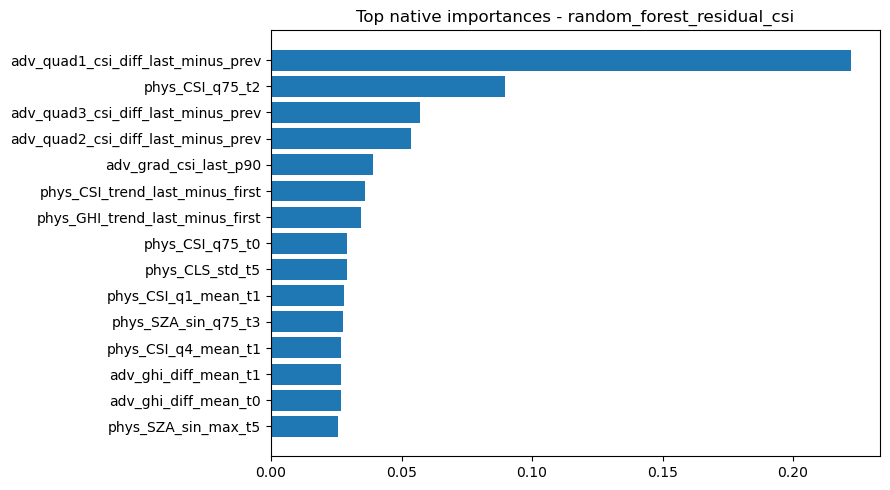

In [17]:
# Construire une table de comparaison pré-DL
all_predictions_pre_dl = {}
all_predictions_pre_dl.update(predictions)
all_predictions_pre_dl.update(supervised_predictions)
all_predictions_pre_dl.update(spatial_predictions)
all_predictions_pre_dl.update(cluster_predictions)

comparison_pre_dl = build_model_diagnostics(
    val_target,
    all_predictions_pre_dl,
    reference_name=MAIN_REFERENCE_NAME,
)["global"]

display(comparison_pre_dl[["model", "RMSE", "MAE", "skill_RMSE_vs_CSI"]].sort_values("RMSE"))

# On privilégie un modèle arbre interprétable
candidate_models = [
    "hist_gb_patch2x2_cluster_feature",
    "hist_gb_patch2x2_residual_csi",
    "hist_gb_residual_csi",
    "extra_trees_residual_csi",
    "random_forest_residual_csi",
]

available_candidates = [m for m in candidate_models if m in model_registry]
if len(available_candidates) == 0:
    raise ValueError("Aucun modèle interprétable disponible dans model_registry.")

best_explain_name = (
    comparison_pre_dl[comparison_pre_dl["model"].isin(available_candidates)]
    .sort_values("RMSE")
    .iloc[0]["model"]
)

best_explain_model = model_registry[best_explain_name]
print("Best explainable model:", best_explain_name)

# Choisir la bonne matrice X + les bons noms de features
if best_explain_name == "hist_gb_patch2x2_cluster_feature":
    X_explain = X_val_tab_clustered
    explain_feature_names = cluster_feature_columns
elif "patch2x2" in best_explain_name:
    X_explain = X_val_tab
    explain_feature_names = feature_names
else:
    X_explain = X_val_tab
    explain_feature_names = feature_names

# Choisir la bonne cible pour l'interprétation
if "patch2x2" in best_explain_name:
    y_explain = residual_patch_val
else:
    y_explain = residual_val

print("X_explain shape:", X_explain.shape)
print("Number of feature names:", len(explain_feature_names))
print("y_explain shape:", y_explain.shape)

# -------------------------
# Native feature importances
# -------------------------
native_imp = model_feature_importances(best_explain_model, explain_feature_names)

if native_imp.empty:
    print(
        f"Native feature importances non disponibles pour {best_explain_name}. "
        "On s'appuie donc sur permutation importance et SHAP."
    )
else:
    display(native_imp.head(20))

    fig, ax = plt.subplots(figsize=(9, 5))
    top_native = native_imp.head(15).sort_values("importance")
    ax.barh(top_native["feature"], top_native["importance"])
    ax.set_title(f"Top native importances - {best_explain_name}")
    plt.tight_layout()
    plt.show()

### Lecture des variables importantes

Si les variables dominantes sont liées à :
- la dynamique récente de `GHI` / `CSI` ;
- certains résumés spatiaux locaux ;
- la géométrie solaire ;

alors l'interprétation est cohérente : le modèle exploite à la fois
- l'état radiatif actuel,
- son évolution récente,
- et le contexte physique imposé par la position du soleil.

,feature,importance_mean,importance_std,baseline_score
0,adv_quad1_csi_diff_last_minus_prev,6.956238e-01,2.751590e-01,1.109846
1,adv_quad3_csi_diff_last_minus_prev,4.243084e-01,7.252651e-02,1.109846
2,adv_grad_csi_last_std,9.269142e-03,2.539390e-03,1.109846
3,phys_GHI_min_t3,4.785148e-03,4.859906e-04,1.109846
4,phys_CSI_min_t3,6.100331e-05,4.313586e-05,1.109846
5,phys_SZA_cos_max_t7,2.220446e-16,0.000000e+00,1.109846
6,phys_SZA_sin_std_t7,2.220446e-16,0.000000e+00,1.109846
7,phys_SZA_cos_q1_mean_t7,2.220446e-16,0.000000e+00,1.109846
8,tex_csi_t-1_glcm_dissimilarity,2.220446e-16,0.000000e+00,1.109846
9,tex_csi_t-1_gabor_max_mean,2.220446e-16,0.000000e+00,1.109846


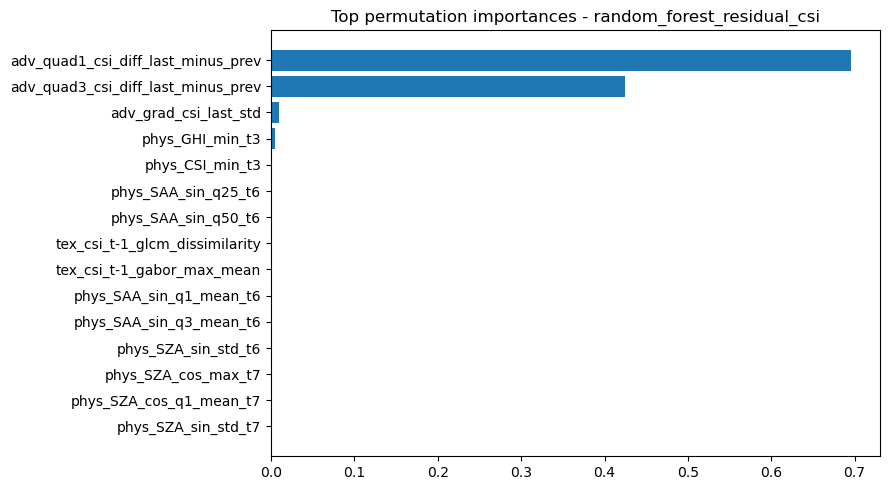

SHAP non disponible ou a échoué : The optional dependency 'shap' is not installed. Use permutation_importance_multioutput as a fallback.


In [18]:
# -------------------------
# Permutation importance
# -------------------------
perm = permutation_importance_multioutput(
    best_explain_model,
    X_explain,
    y_explain,
    explain_feature_names,
    n_repeats=3,
    random_state=RANDOM_STATE,
    max_features=40 if RUN_FAST else None,
)
display(perm.importance.head(20))

fig, ax = plt.subplots(figsize=(9, 5))
top_perm = perm.importance.head(15).sort_values("importance_mean")
ax.barh(top_perm["feature"], top_perm["importance_mean"])
ax.set_title(f"Top permutation importances - {best_explain_name}")
plt.tight_layout()
plt.show()

# -------------------------
# SHAP (si disponible)
# -------------------------
try:
    shap_values, X_shap, shap_feature_names = compute_tree_shap_values(
        best_explain_model,
        X_explain,
        explain_feature_names,
        output_index=0,
        max_samples=200 if not RUN_FAST else 80,
    )

    import shap
    import matplotlib.pyplot as plt

    shap.plots.bar(shap_values, max_display=15, show=False)
    plt.tight_layout()
    plt.show()

    shap.plots.beeswarm(shap_values, max_display=15, show=False)
    plt.tight_layout()
    plt.show()

    sample_idx = 0
    shap.plots.waterfall(shap_values[sample_idx], max_display=15, show=False)
    plt.tight_layout()
    plt.show()

except Exception as exc:
    print("SHAP non disponible ou a échoué :", exc)

### SHAP et permutation importance

- **Permutation importance** dit quelles variables dégradent le plus la performance quand on les casse ;
- **SHAP** montre en plus dans quel sens une variable pousse une prédiction vers le haut ou vers le bas.

Pour les modèles arbres, SHAP est généralement plus informatif que LIME.  
LIME peut rester un bonus local si tu veux illustrer 1 ou 2 cas particuliers.

## 10. Deep learning optionnel

Cette section est surtout destinée à **Colab**.  
L'objectif n'est plus de corriger un résidu moyen ou un résidu par patch, mais d'apprendre une **carte résiduelle complète**.

In [19]:
dl_predictions = {}

if RUN_DL:
    # Baseline neuronale tabulaire legere, toujours executable avec scikit-learn.
    mlp_model = fit_mlp_residual_mean(
        X_train_tab,
        residual_train,
        hidden_layer_sizes=(64, 32),
        random_state=RANDOM_STATE,
        max_iter=80 if RUN_FAST else 300,
    )
    mlp_residual = mlp_model.predict(X_val_tab)
    dl_predictions["mlp_residual_csi"] = add_residual_mean_to_baseline(
        y_pred_persistence_csi,
        mlp_residual,
    )

    X_train_convlstm, y_train_convlstm, convlstm_channels = prepare_convlstm_training_data(
        train_arrays_raw,
        train_target,
        baseline=y_pred_train_csi,
    )
    X_val_convlstm, y_val_convlstm, _ = prepare_convlstm_training_data(
        val_arrays_raw,
        val_target,
        baseline=y_pred_persistence_csi,
    )
    print("ConvLSTM input:", X_train_convlstm.shape, "| channels:", convlstm_channels)

    if has_tensorflow():
        convlstm_model = build_convlstm_residual_model(
            input_shape=X_train_convlstm.shape[1:],
            n_horizons=len(FORECAST_HORIZONS_MINUTES),
            learning_rate=1e-3,
        )
        history = convlstm_model.fit(
            X_train_convlstm,
            y_train_convlstm,
            validation_data=(X_val_convlstm, y_val_convlstm),
            epochs=3 if RUN_FAST else 25,
            batch_size=4 if RUN_FAST else 16,
            verbose=0,
        )
        residual_pred_val = target_from_channels_last(convlstm_model.predict(X_val_convlstm, verbose=0))
        y_pred_convlstm = np.maximum(y_pred_persistence_csi + residual_pred_val, 0.0)
        dl_predictions["convlstm_residual_csi_fullmap"] = y_pred_convlstm
        print("ConvLSTM executee.")
    else:
        print("TensorFlow indisponible : ConvLSTM non executee.")
else:
    print("RUN_DL = False : section deep learning sautee.")

ConvLSTM input: (25, 4, 51, 51, 7) | channels: ['CSI', 'GHI', 'CLS', 'SZA_sin', 'SZA_cos', 'SAA_sin', 'SAA_cos']
TensorFlow indisponible : ConvLSTM non executee.


### Pourquoi garder cette section

La CNN simple traite les images passees comme des canaux independants. Une ConvLSTM est mieux alignee avec la problematique: elle lit une sequence d'images et apprend directement la dynamique spatio-temporelle. Le notebook tente donc une ConvLSTM si TensorFlow est disponible; sinon il garde un MLP residuel comme fallback leger pour que le rendu reste executable.

,model,RMSE,MAE,MBE,MedAE,P90AE,nRMSE,R2,MAPE,corr_spatial_mean,skill_RMSE_vs_CSI
0,random_forest_residual_csi,13.284251,6.394910,0.072374,1.884956,19.243642,0.036177,0.990813,2.110221,0.999985,5.878961e-02
1,extra_trees_residual_csi,13.306444,6.325711,0.271465,1.691467,19.105670,0.036238,0.990782,2.091431,0.999959,5.564223e-02
2,hist_gb_residual_csi,13.350894,6.699421,0.337312,2.685139,19.355685,0.036359,0.990721,2.186785,0.999948,4.932240e-02
3,mlp_residual_csi,13.364521,6.678017,0.778333,2.579407,19.099847,0.036396,0.990702,2.126510,0.999932,4.738074e-02
4,ridge_residual_csi,13.384689,6.527440,-0.144588,1.889633,19.330798,0.036451,0.990673,2.151840,0.999911,4.450349e-02
5,elasticnet_residual_csi,13.498168,6.846403,-0.376817,2.025558,19.517313,0.036760,0.990515,2.273741,0.999863,2.823293e-02
6,hist_gb_patch2x2_cluster_feature,13.558795,7.221085,1.545870,2.977783,19.366890,0.036925,0.990429,2.503989,0.999943,1.948389e-02
7,hist_gb_patch2x2_residual_csi,13.564344,7.192806,1.611464,2.884918,19.355176,0.036940,0.990421,2.500134,0.999936,1.868119e-02
8,persistence_csi,13.692846,7.372206,-0.417489,3.536774,19.419833,0.037290,0.990239,2.556798,0.999774,5.333511e-11
9,advective_csi,18.462959,9.137542,-0.139323,3.626373,24.591437,0.050280,0.982254,3.224402,0.999755,-8.180892e-01


Modèles qui battent la persistance CSI:


,model,RMSE,MAE,skill_RMSE_vs_CSI
0,random_forest_residual_csi,13.284251,6.394910,0.058790
1,extra_trees_residual_csi,13.306444,6.325711,0.055642
2,hist_gb_residual_csi,13.350894,6.699421,0.049322
3,mlp_residual_csi,13.364521,6.678017,0.047381
4,ridge_residual_csi,13.384689,6.527440,0.044503
5,elasticnet_residual_csi,13.498168,6.846403,0.028233
6,hist_gb_patch2x2_cluster_feature,13.558795,7.221085,0.019484
7,hist_gb_patch2x2_residual_csi,13.564344,7.192806,0.018681


Meilleur modèle global selon RMSE: random_forest_residual_csi


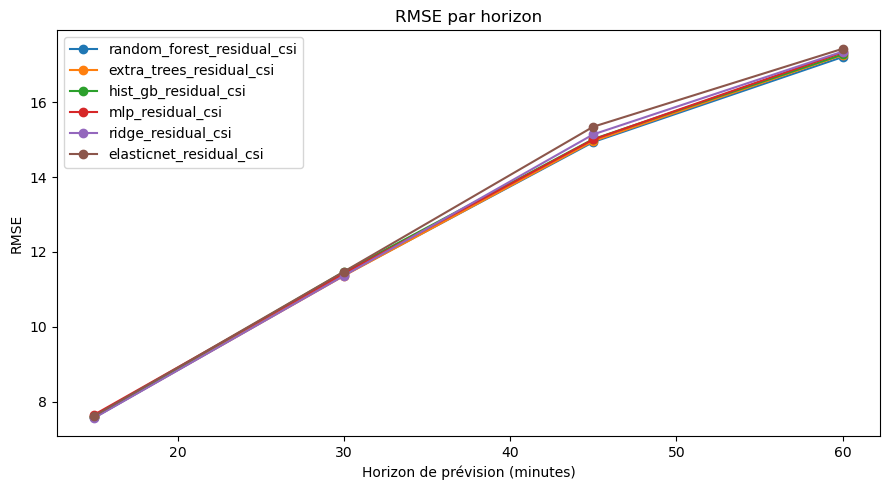

,model,cluster,regime,n,RMSE,MAE,bias,P90AE,nRMSE,skill_RMSE_vs_CSI
2,random_forest_residual_csi,0,partiellement_nuageux,3,8.056035,3.456865,-0.066242,4.504565,0.020796,1.641222e-01
0,persistence_csi,0,partiellement_nuageux,3,8.811502,4.346719,-0.090239,6.155542,0.022746,1.287953e-10
3,random_forest_residual_csi,1,couvert,4,16.129168,8.598445,0.176336,23.810623,0.045813,3.606226e-02
1,persistence_csi,1,couvert,4,16.428105,9.641323,-0.662926,24.035141,0.046663,3.705314e-11


In [20]:
all_predictions = {}
all_predictions.update(predictions)
all_predictions.update(supervised_predictions)
all_predictions.update(spatial_predictions)
all_predictions.update(cluster_predictions)
if RUN_DL:
    all_predictions.update(dl_predictions)

final_diagnostics = build_model_diagnostics(
    val_target,
    all_predictions,
    reference_name=MAIN_REFERENCE_NAME,
)

final_table = final_diagnostics["global"]
display(final_table)

interesting = final_table.query("model != 'persistence_csi' and skill_RMSE_vs_CSI > 0")
if len(interesting):
    print("Modèles qui battent la persistance CSI:")
    display(interesting[["model", "RMSE", "MAE", "skill_RMSE_vs_CSI"]])
else:
    print("Aucun modèle ne bat la persistance CSI sur ce run.")

best_model_name = final_table.iloc[0]["model"]
print("Meilleur modèle global selon RMSE:", best_model_name)

fig, ax = plt.subplots(figsize=(9, 5))
plot_models = [name for name in final_table["model"].head(min(6, len(final_table)))]
for model_name in plot_models:
    h = final_diagnostics["by_horizon"].query("model == @model_name")
    ax.plot(h["horizon_min"], h["RMSE"], marker="o", label=model_name)
ax.set_xlabel("Horizon de prévision (minutes)")
ax.set_ylabel("RMSE")
ax.set_title("RMSE par horizon")
ax.legend()
plt.tight_layout()
plt.show()

# Comparaison par cluster entre baseline CSI et meilleur modèle tabulaire pré-DL
best_tabular_name = (
    comparison_pre_dl.sort_values("RMSE").iloc[0]["model"]
)
cluster_perf = pd.concat(
    [
        metrics_by_cluster(
            val_target,
            y_pred_persistence_csi,
            val_clusters,
            "persistence_csi",
            cluster_name_map=cluster_name_map,
            reference_pred=y_pred_persistence_csi,
        ),
        metrics_by_cluster(
            val_target,
            all_predictions[best_tabular_name],
            val_clusters,
            best_tabular_name,
            cluster_name_map=cluster_name_map,
            reference_pred=y_pred_persistence_csi,
        ),
    ],
    ignore_index=True,
)
display(cluster_perf.sort_values(["cluster", "RMSE"]))

## Conclusion operationnelle

Les ameliorations ajoutees renforcent la logique physique du notebook:

- la persistance CSI reste la reference principale du skill score;
- l'advective CSI teste explicitement l'apport du deplacement nuageux;
- les modeles supervises exploitent desormais des features de mouvement et de texture;
- le clustering peut expliquer les regimes non seulement par le niveau de CSI, mais aussi par la complexite spatiale;
- la section deep learning est prete pour une ConvLSTM, plus adaptee qu'une CNN simple au caractere sequentiel du probleme.

Les variables de vent ne sont pas presentes dans les fichiers Copernicus fournis. Le pipeline accepte toutefois des champs `U/V` si une source meteo externe ou une variante enrichie du challenge est ajoutee plus tard.